# Mock Member Health Analysis - Model_interpretation

## 1. Imports

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

## 2. Load Processed Dataset

In [17]:
df = pd.read_csv("../data/processed/member_analysis_ready.csv")
df.head()

,member_id,age,gender,region,plan_type,sdoh_risk_score,chronic_condition_count,engagement_score,pcp_attributed_24mo,prior_awv_count,...,engagement_group,age_group,high_cost_member,chronic_burden_group,sdoh_risk_group,prior_awv_group,total_acute_visits,acute_utilization_group,pcp_status,has_acute_utilization
0,M00001,69,Male,Suburban,Medicare Advantage,40.7,2,68.9,1,1,...,Q4_High,65-79,1,Moderate,Q1_Low,1,2,Low,Attributed,1
1,M00002,32,Female,Urban,DSNP,80.0,3,30.4,0,0,...,Q1_Low,18-34,0,Moderate,Q4_High,0,2,Low,Not Attributed,1
2,M00003,89,Female,Suburban,Medicare Advantage,49.6,3,86.3,1,3,...,Q4_High,80+,0,Moderate,Q2,3,0,NaN,Attributed,0
3,M00004,78,Male,Suburban,Medicare Advantage,45.7,4,63.1,1,1,...,Q4_High,65-79,1,High,Q1_Low,1,3,Moderate,Attributed,1
4,M00005,38,Male,Suburban,Medicare Advantage,32.4,0,55.6,0,0,...,Q4_High,35-49,0,Low,Q1_Low,0,0,NaN,Not Attributed,0


In [18]:
target = "awv_completed"

drop_cols = [
    "member_id",  # Identifier, not a predictive feature
    target,  # Target variable must be removed from predictors
    "monthly_cost",  # Cost outcome should not be used to predict AWV completion
    "high_cost_member"  # Derived from monthly_cost, so remove it too
]

X = df.drop(columns=drop_cols)  # Create predictor dataset after removing leakage/outcome-style columns
y = df[target]  # Define the target variable

## 3. Rebuild Baseline Logistic Regression

In [19]:
X_train, X_test, y_train, y_test = train_test_split( 
    X,y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
) # Stratify by y to maintain the same proportion of classes in both training and testing sets, which is important for classification problems.


In [20]:
categorical_cols = X.select_dtypes(
    include=["object", "string", "category", "bool"]  # Select categorical/text-like columns
).columns.tolist()  # Store categorical column names

numeric_cols = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]  # Select numeric columns
).columns.tolist()  # Store numeric column names

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categorical_cols
        ),  # One-hot encode categorical predictors

        (
            "num",
            StandardScaler(),
            numeric_cols
        )  # Standardize numeric predictors for logistic regression coefficient interpretation
    ]
)

In [22]:
log_model = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=3000)) 
])
log_model.fit(X_train, y_train) # Fit the logistic regression model to the training data using the defined pipeline, which includes preprocessing steps for both categorical and numeric features. The max_iter=3000 parameter is set to ensure convergence of the logistic regression algorithm, especially if the dataset is large or has many features.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## 4.Review Class Balance

In [23]:
df["awv_completed"].value_counts(normalize = True) # Check the distribution of the target variable to understand class imbalance, which can impact model performance and may require techniques such as resampling or class weighting if the classes are highly imbalanced.


awv_completed
1    0.519333
0    0.480667
Name: proportion, dtype: float64

## 5. Evaluate Predictions More Deeply

In [24]:
y_pred = log_model.predict(X_test) # Generate predicted class labels for the test set using the fitted logistic regression model. This will be used to evaluate the model's performance in terms of classification metrics such as accuracy, precision, recall, and F1-score.
y_prob = log_model.predict_proba(X_test)[:,1] # Generate predicted probabilities for the positive class (class 1) for the test set using the fitted logistic regression model. This will be used for evaluating the model's performance in terms of probabilistic metrics such as AUC-ROC.

In [25]:
print("Recall:", recall_score(y_test, y_pred, zero_division=0))  # Measure how many actual positives were captured

print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))  # Balance precision and recall

print("ROC AUC:", roc_auc_score(y_test, y_prob))  # Measure ranking ability across probability thresholds

print("\nConfusion Matrix:")  # Print raw classification error breakdown
print(confusion_matrix(y_test, y_pred))  # Show true negatives, false positives, false negatives, and true positives

print("\nClassification Report:")  # Print precision, recall, and F1 by class
print(classification_report(y_test, y_pred, zero_division=0))  # Show full classification report

Recall: 0.7339743589743589
F1 Score: 0.7178683385579937
ROC AUC: 0.7636774394586895

Confusion Matrix:
[[191  97]
 [ 83 229]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.66      0.68       288
           1       0.70      0.73      0.72       312

    accuracy                           0.70       600
   macro avg       0.70      0.70      0.70       600
weighted avg       0.70      0.70      0.70       600



## 6.Interpret Logistic Regression Coefficients

### Step A: get transformed feature names

In [26]:
ohe = log_model.named_steps["preprocessor"].named_transformers_["cat"] # Access the OneHotEncoder from the preprocessing step of the pipeline to retrieve the feature names for the encoded categorical variables. This will allow us to understand which features correspond to which original categorical variables after encoding.
encoded_cat_features = ohe.get_feature_names_out(categorical_cols) # Get the feature names for the encoded categorical variables using the get_feature_names_out method of the OneHotEncoder, which will return the new feature names after encoding based on the original categorical column names.
all_feature_names = list(encoded_cat_features) + numeric_cols # Combine the encoded categorical feature names with the original numeric column names to create a complete list of feature names that correspond to the features used in the logistic regression model after preprocessing.

### Step B: get coefficients

In [27]:
coefficients = log_model.named_steps["model"].coef_[0]  # Extract logistic regression coefficients for the positive class

coef_df = pd.DataFrame({
    "feature": all_feature_names,  # Store transformed feature names
    "coefficient": coefficients  # Store model coefficients on the log-odds scale
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()  # Create absolute coefficient size for sorting
coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])  # Convert log-odds coefficients into odds ratios

coef_df = coef_df.sort_values(
    "abs_coefficient",
    ascending=False
)  # Sort features by strongest coefficient magnitude

coef_df.head(15)  # Display top coefficients


,feature,coefficient,abs_coefficient,odds_ratio
7,engagement_group_Q4_High,0.590416,0.590416,1.804740
11,age_group_80+,-0.416575,0.416575,0.659301
10,age_group_65-79,-0.347263,0.347263,0.706619
6,engagement_group_Q3,0.313061,0.313061,1.367605
24,engagement_score,0.309301,0.309301,1.362473
21,age,0.306357,0.306357,1.358467
17,acute_utilization_group_Low,0.276675,0.276675,1.318737
5,engagement_group_Q2,0.252619,0.252619,1.287393
0,gender_Male,0.219483,0.219483,1.245433
9,age_group_50-64,-0.201662,0.201662,0.817372


## 7. Test Different Classification Threshold

In [28]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7] # Define a range of thresholds to evaluate how the model's performance metrics change when we classify instances as positive based on different probability cutoffs. This is important because the default threshold of 0.5 may not always be optimal, especially in cases of class imbalance or when the costs of false positives and false negatives are different.

threshold_results = []

for threshold in thresholds:
    y_pred_thresh = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred_thresh),
        "precision": precision_score(y_test, y_pred_thresh, zero_division = 0),
        "recall": recall_score(y_test, y_pred_thresh, zero_division = 0 ),
        "f1_score": f1_score(y_test, y_pred_thresh, zero_division = 0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df


,threshold,accuracy,precision,recall,f1_score
0,0.3,0.641667,0.600832,0.926282,0.728878
1,0.4,0.686667,0.656566,0.833333,0.734463
2,0.5,0.700000,0.702454,0.733974,0.717868
3,0.6,0.680000,0.747934,0.580128,0.653430
4,0.7,0.640000,0.811688,0.400641,0.536481


## 8. Compare Threshold Tradeoffs

In [29]:
best_f1_threshold = threshold_df.sort_values("f1_score", ascending = False).iloc[0] # Sort the threshold results by F1-score in descending order and select the row with the highest F1-score to identify the optimal threshold for classification based on the balance of precision and recall.
best_f1_threshold


threshold    0.400000
accuracy     0.686667
precision    0.656566
recall       0.833333
f1_score     0.734463
Name: 1, dtype: float64

## 9. Plot Threshold Tradeoffs

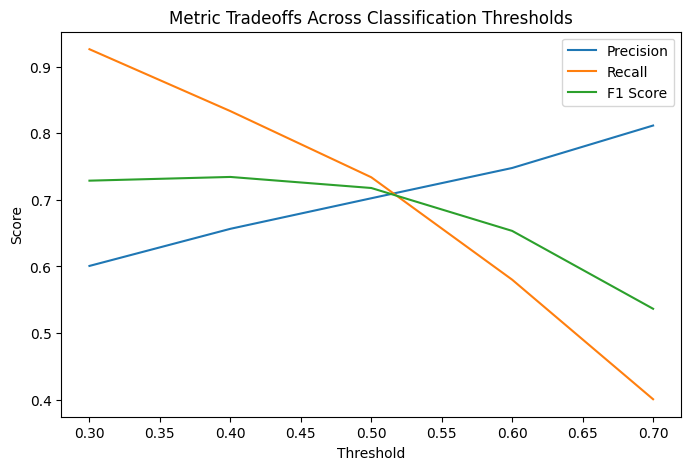

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1_score"], label="F1 Score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Metric Tradeoffs Across Classification Thresholds")
plt.legend()
plt.show()

## Findings

1. The target variable is imbalanced toward AWV-completed members, so accuracy alone can overstate model quality.

2. Logistic regression coefficients show conditional associations with predicted AWV completion. Positive coefficients increase the predicted log-odds of AWV completion, while negative coefficients decrease the predicted log-odds, holding other included variables constant.

3. Because numeric variables were standardized, numeric coefficients represent the change in log-odds associated with a one-standard-deviation increase in the predictor. Dummy-variable coefficients represent differences relative to the omitted reference category.

4. Odds ratios were added to make coefficient interpretation more intuitive. Odds ratios above 1 indicate higher predicted odds of AWV completion, while odds ratios below 1 indicate lower predicted odds.

5. Classification performance changed across thresholds, showing that the default 0.50 cutoff is only one operating choice. The threshold with the highest F1 score in this test set should be interpreted as test-set-specific, not universally optimal.

6. These relationships reflect learned patterns in synthetic data and should not be interpreted as causal effects.